In [40]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [41]:
df=pd.read_csv("C:\\Users\\Bhavani\\OneDrive\\Documents\\ml-tekwork\\revision_practice\\dt_regressor\\insurance.csv")
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [42]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


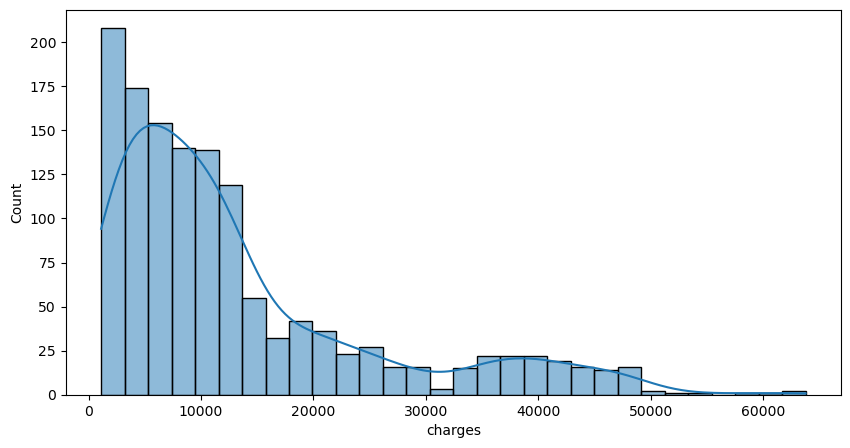

In [43]:
#target variable anyalysis
plt.figure(figsize=(10,5))

sns.histplot(
    df['charges'],
    kde=True
)

plt.show()

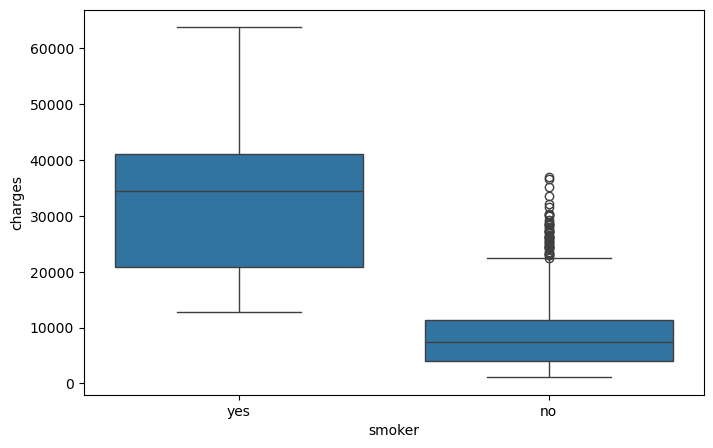

In [44]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='smoker',
    y='charges',
    data=df
)

plt.show()

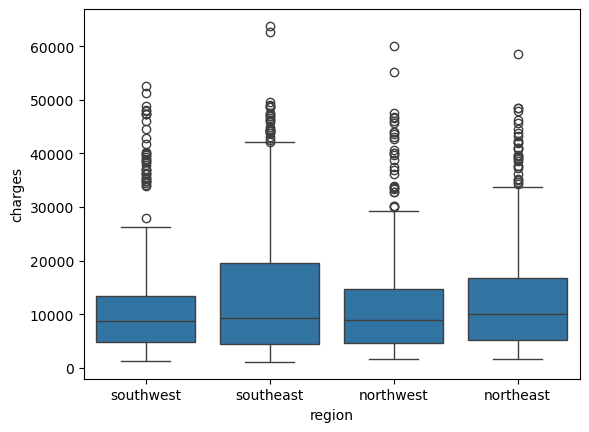

In [45]:
sns.boxplot(
    x='region',
    y='charges',
    data=df
)

plt.show()

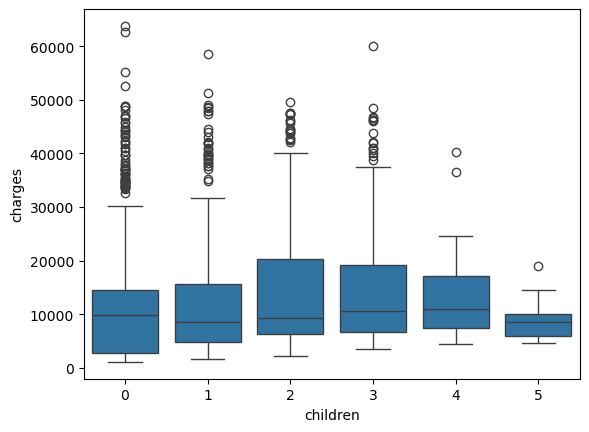

In [46]:
sns.boxplot(
    x='children',
    y='charges',
    data=df
)

plt.show()

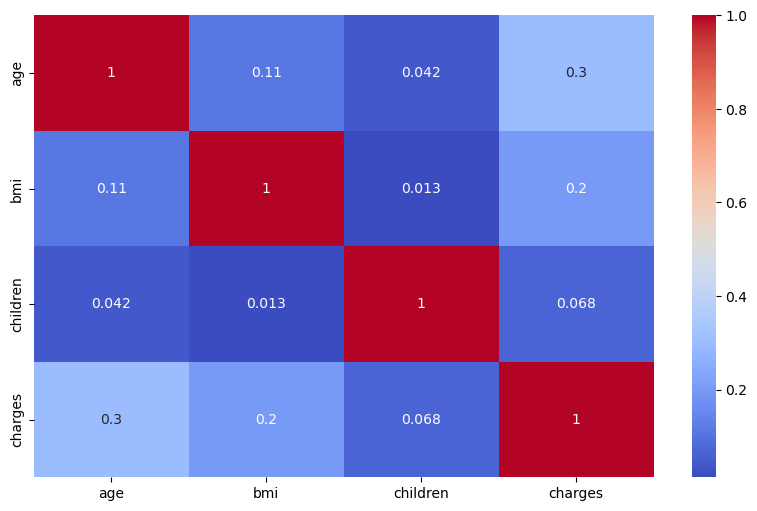

In [47]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

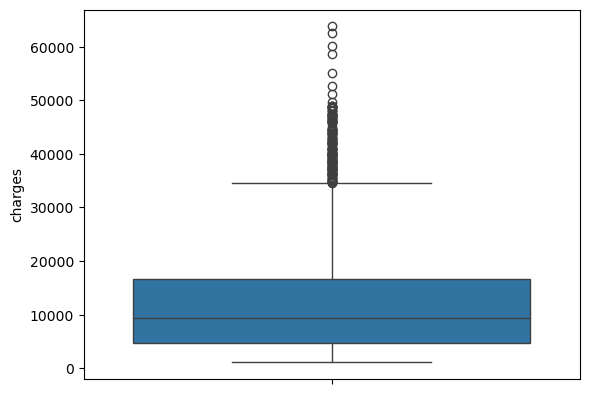

In [48]:
sns.boxplot(df['charges'])

plt.show()

In [49]:
df['bmi_category'] = pd.cut(
    df['bmi'],
    bins=[0,18.5,25,30,100],
    labels=[
        'Underweight',
        'Normal',
        'Overweight',
        'Obese'
    ]
)

In [50]:
df['health_risk'] = (
    df['age'] *
    df['bmi']
)

In [51]:
df['high_risk_smoker'] = np.where(
    (df['smoker']=='yes') &
    (df['bmi'] > 30),
    1,
    0
)

In [52]:
y = df['charges']
X = df.drop('charges', axis=1)
X = pd.get_dummies(
    X,
    drop_first=True
)

In [53]:
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [54]:
model = DecisionTreeRegressor(
    random_state=42
)

model.fit(
    x_train,
    y_train
)
y_pred = model.predict(x_test)

In [55]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

print("MAE:", mae)
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

print("RMSE:", rmse)
r2 = r2_score(
    y_test,
    y_pred
)

print("R2 Score:", r2)
print("Train Score:", model.score(x_train, y_train))

print("Test Score:", model.score(x_test, y_test))

MAE: 2830.668102738806
RMSE: 6113.497561149344
R2 Score: 0.7592582427498968
Train Score: 0.9983078124756305
Test Score: 0.7592582427498968


In [58]:
from sklearn.model_selection import GridSearchCV
params = {
    'max_depth': [3,5,7,10],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4]
}
grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    params,
    cv=5,
    scoring='neg_mean_absolute_error'
)
grid.fit(x_train, y_train)
best_model = grid.best_estimator_
y_pred = best_model.predict(x_test)
print(
    "MAE:",
    mean_absolute_error(y_test, y_pred)
)

print(
    "RMSE:",
    np.sqrt(mean_squared_error(y_test, y_pred))
)

print(
    "R2:",
    r2_score(y_test, y_pred)
)


MAE: 2551.865465835175
RMSE: 4403.826736816675
R2: 0.875079881545254


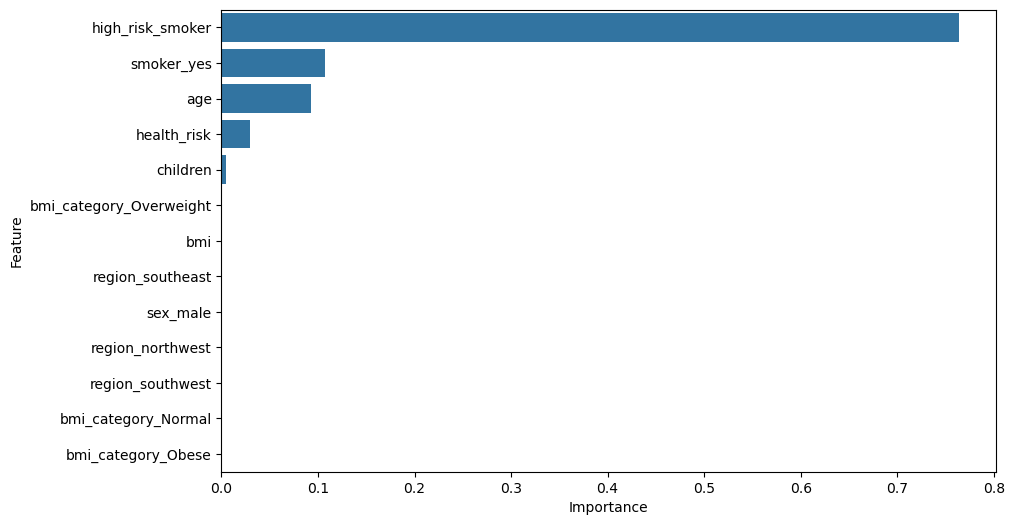

In [60]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.show()

In [62]:
import pickle
pickle.dump(
    best_model,
    open('../models/decision_tree_model.pkl', 'wb')
)
pickle.dump(
    X.columns,
    open('../models/columns.pkl', 'wb')
)